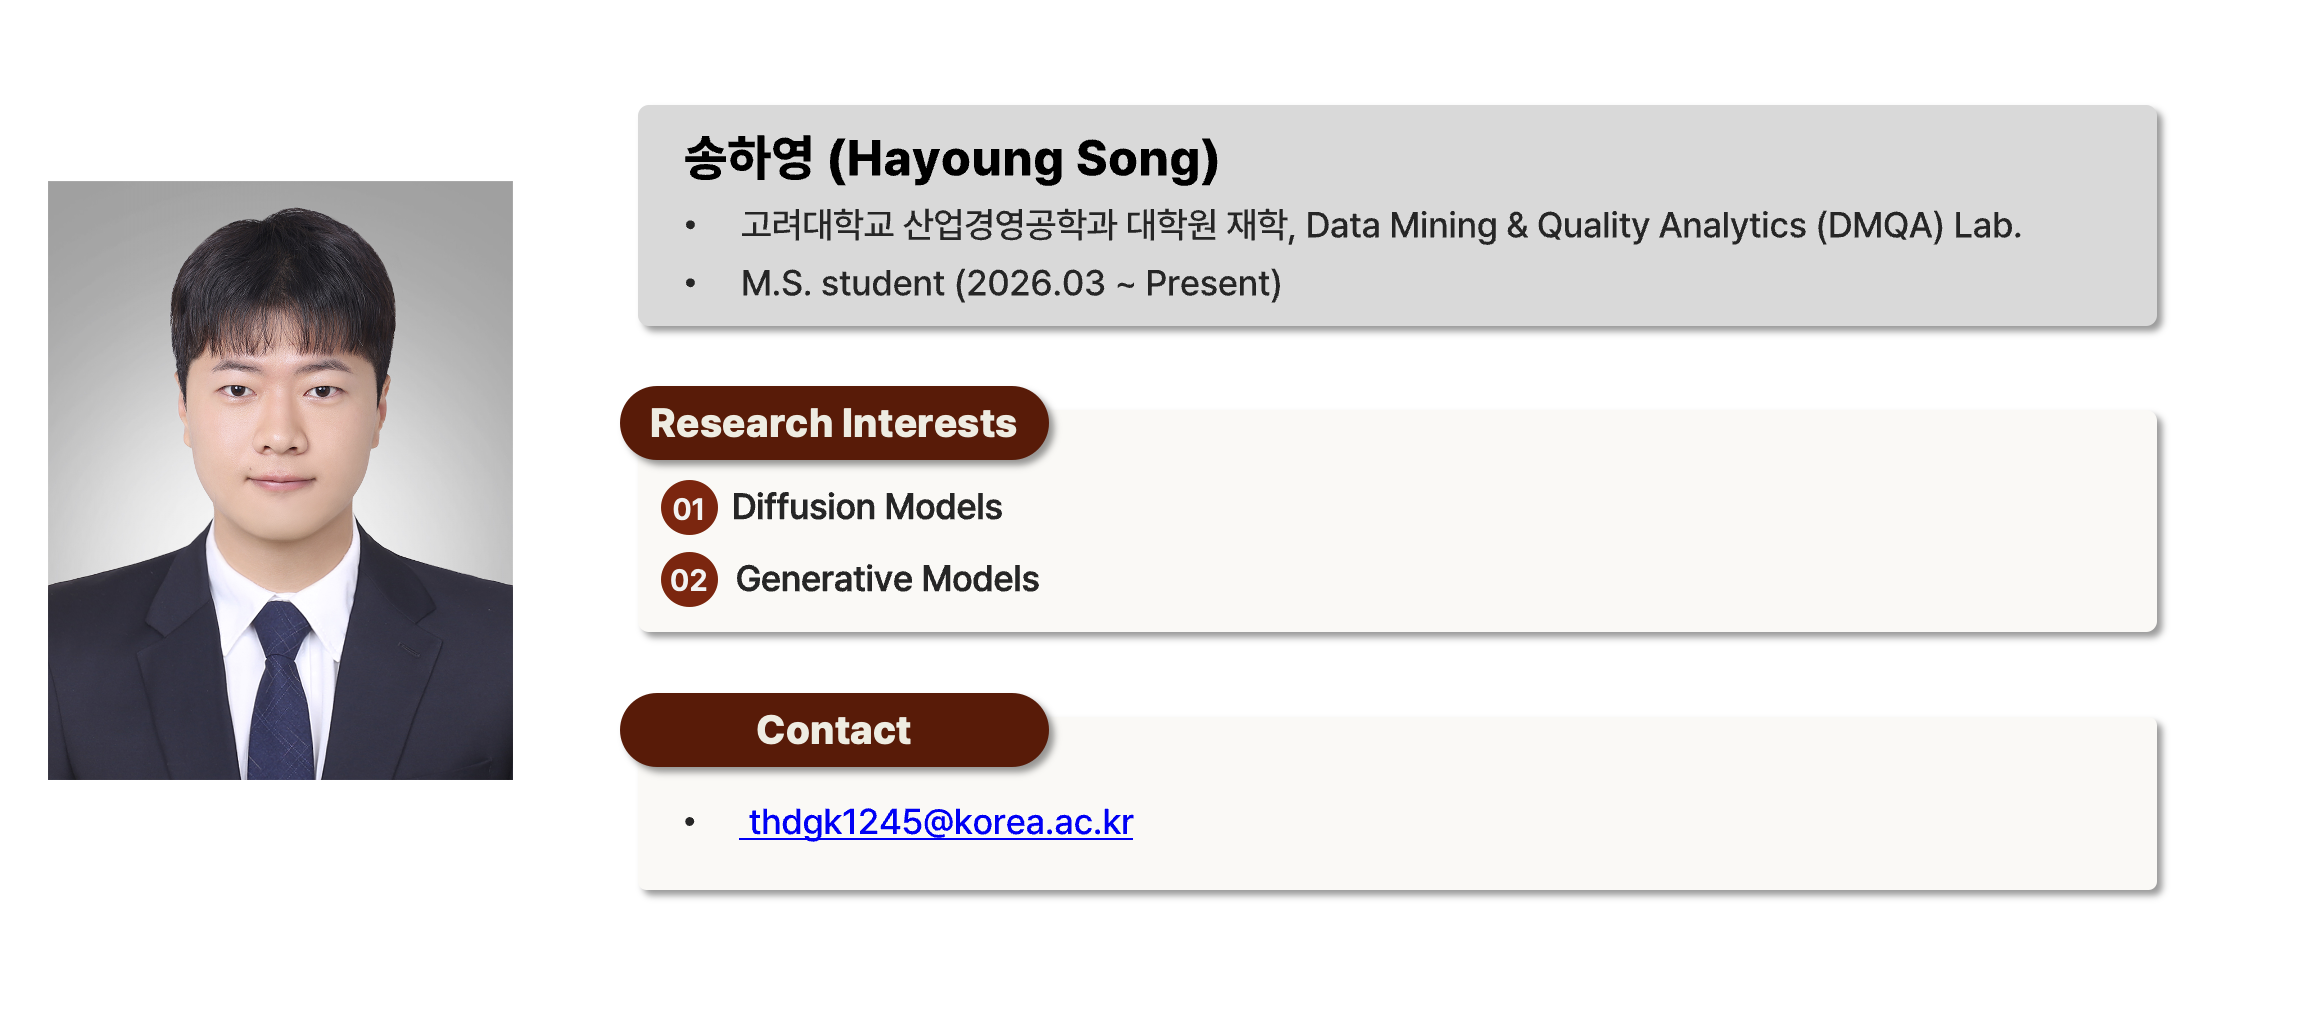

In [76]:
from IPython.display import Image # ipynb 파일에서 이미지 파일을 불러오고자 할 때 필요한 라이브러리
Image('../../data/figure/intro.png')

# 01. Python Basics — 간단한 데이터에서 제조 데이터 분석까지

**목표:** 익숙한 데이터로 사용법을 익히고, 같은 코드를 제조 데이터에 적용합니다.
각 주제는 **A. 간단한 예제 → B. 제조 데이터 예제 → 결과 확인 / 직접 해보기** 순서입니다.
정답을 보기 전에 출력을 예상하고, 한 가지 값을 바꾼 뒤 무엇이 달라졌는지 말해보세요.

Data Load → Data Structure → Data Quality → Summary Statistics → Visualization → Observation → Question/Hypothesis

**제조 실습 데이터는 제조 공정을 모사하여 만든 제조 합성 데이터(synthetic manufacturing data)입니다.** 실제 기업의 공정·측정 데이터가 아닙니다. CSV는 400행이며, 학습을 위해 일부 결측치와 이상치를 의도적으로 포함했습니다. 제조 예제의 기준값과 관계는 실제 품질 규격이나 물리식을 뜻하지 않습니다.

| 학습 구간 | 일상 사례 | 제조 적용 |
|---|---|---|
| 0–5. Python | 인사, 장보기, 점수, 카페 대기 시간 | 장비 정보, 공정 조건, 측정값 판정 |
| 6. NumPy | 걸음 수, 점수의 평균·산포 | 온도 보정, 온도 분포, 조건 선택 |
| 7–9. Pandas | 작은 카페 주문표 | 400행 제조 합성 CSV의 구조·품질·그룹 비교 |
| 10. Matplotlib | 카페 대기 시간과 주문 | 공정 온도·센서·품질값 비교 |
| 11. 종합 연습 | 일상 데이터 workflow 정리 | 같은 순서로 제조 데이터 질문 만들기 |

**진행 안내:** 예제 실행·토의 100–120분, 직접 해보기와 종합 연습 40–60분을 별도로 배정합니다.
두 번에 나누면 0–6(Python·NumPy), 7–11(Pandas·EDA) 순서로 진행하세요.
두 번째 회차도 앞부분을 실행해 변수를 준비합니다. `직접 해보기`의 코드 셀은 예제와 별도 변수명을 사용합니다.

## 0. Jupyter Notebook 소개

- **Markdown**: 설명·질문·관찰 기록. 더블클릭하면 편집할 수 있습니다.
- **Code**: Python 코드. `Shift + Enter`로 실행하고 다음 셀로 이동합니다.
- **Output**: 코드 아래의 값·표·그래프. 실행 중 `[*]`가 보이면 기다립니다.

`Ctrl + Enter`는 현재 셀을 실행합니다. 변수는 Kernel 메모리에 남습니다.
실행 순서가 헷갈리면 **Restart Kernel and Run All Cells**로 위에서부터 다시 실행하세요.

### 0-1. print()로 결과 확인하기

`print()`는 현재 값이나 진행 상태를 보여줍니다. 따옴표 안은 문자열입니다.

**A. 간단한 예제 — 인사와 계산**

In [1]:
print("안녕하세요!")
print(3 + 2)
print("주문 수:", 3 + 2)

안녕하세요!
5
주문 수: 5


**B. 제조 데이터에 적용**

같은 방식으로 장비명과 측정 건수를 확인합니다.

In [2]:
print("분석 장비:", "EQ_A")
print("측정 건수:", 3 + 2)

분석 장비: EQ_A
측정 건수: 5


**결과 확인 / 연결하기:** `print("3 + 2")`는 계산할까요? 따옴표가 있을 때와 없을 때의 출력을 비교하세요.

## 1. 변수와 기본 자료형

변수는 값에 붙인 이름입니다. `=`는 저장, `==`는 같은지 비교하는 연산입니다.

### 1-1. int / float / str / bool / type()

서로 다른 종류의 정보를 구분해야 올바른 계산을 할 수 있습니다.

**A. 간단한 예제 — 카페 주문 한 건**

In [3]:
menu = "latte"             # str: 이름
cup_count = 2              # int: 개수
rating = 4.5               # float: 소수
is_takeout = True          # bool: 참/거짓
print(menu, type(menu))
print(cup_count, type(cup_count))
print(rating, type(rating))
print(is_takeout, type(is_takeout))

latte <class 'str'>
2 <class 'int'>
4.5 <class 'float'>
True <class 'bool'>


**B. 제조 데이터에 적용**

메뉴명은 장비명으로, 주문 개수는 Recipe 번호로 바뀌어도 자료형의 사용법은 같습니다.

In [4]:
equipment = "EQ_A"
temperature = 430.5
recipe_no = 3
is_abnormal = False
print(equipment, type(equipment))
print(temperature, type(temperature))
print(recipe_no, type(recipe_no))
print(is_abnormal, type(is_abnormal))

EQ_A <class 'str'>
430.5 <class 'float'>
3 <class 'int'>
False <class 'bool'>


**결과 확인 / 연결하기:** Recipe 번호는 int여도 크기를 비교하는 측정값이 아니라 조건을 구분하는 이름일 수 있습니다.

### 1-2. 계산 결과를 변수에 저장하기

`+`, `-`, `*`, `/`로 계산하고 결과에 의미 있는 이름을 붙입니다.

**A. 간단한 예제 — 장보기 금액**

In [5]:
unit_price = 3000
quantity = 3
discount = 500
total_price = unit_price * quantity - discount
print("결제 금액:", total_price)
print("개당 결제 금액:", total_price / quantity)

결제 금액: 8500
개당 결제 금액: 2833.3333333333335


**B. 제조 데이터에 적용**

금액의 차이를 계산하듯 목표 온도와 측정 온도의 차이를 계산합니다.

In [6]:
target_temp = 430.0
measured_temp = 432.5
temp_difference = measured_temp - target_temp
print("목표 대비 차이:", temp_difference)
print("목표 초과 여부:", measured_temp > target_temp)

목표 대비 차이: 2.5
목표 초과 여부: True


**결과 확인 / 연결하기:** 총액은 8,500, 온도 차이는 +2.5입니다. 변수에 저장한 계산 결과는 나중에 입력 변수를 바꾼다고 자동 갱신되지 않으므로 계산 셀도 다시 실행하세요.

### 1-3. 숫자로 보이는 문자열

CSV에서 읽은 숫자가 문자열일 수 있습니다. 필요한 값만 `int()` 또는 `float()`로 변환합니다.

**A. 간단한 예제 — 문자로 적힌 주문 개수**

In [7]:
quantity_text = "3"
print(quantity_text + "2")           # 문자열 연결
print(int(quantity_text) + 2)        # 숫자 덧셈

32
5


**B. 제조 데이터에 적용**

온도는 숫자로 변환하지만 장비 코드의 앞자리 0은 의미가 있으므로 문자열로 유지합니다.

In [8]:
temperature_text = "430.5"
equipment_code = "001"
print(float(temperature_text) - 430)
print("장비 코드:", equipment_code)

0.5
장비 코드: 001


**결과 확인 / 연결하기:** `"32"`와 `5`는 왜 다른가요? `"430 C"`처럼 단위 문자가 섞인 값은 그대로 float 변환이 되지 않으므로 원본 형식을 먼저 확인합니다.

### 직접 해보기 · 변수와 비교

음료 4잔의 총액과 온도 차이를 각각 출력하세요. 

먼저 결과를 예상하고 아래 셀을 완성하세요. TODO를 남겨도 전체 실행에는 문제가 없습니다.

In [ ]:
practice_price = 2500
practice_cups = 4
practice_target = 430.0
practice_measured = 428.0
# TODO: 총액, 측정값 - 목표값, 측정값 < 목표값을 출력하세요.


False


<details>
<summary>실습 후 확인할 기준</summary>

총액은 10,000, 온도 차이는 −2.0, 목표보다 낮은지 비교한 결과는 True입니다.

</details>

## 2. 기본 자료구조: list와 dictionary

값이 여러 개일 때 순서로 찾을지, 이름으로 찾을지에 따라 자료구조를 선택합니다.

### 2-1. list, indexing, slicing

list는 값을 순서대로 저장합니다. 첫 위치는 `0`, 마지막 위치는 `-1`입니다. `[시작:끝]`은 끝 위치를 제외합니다.

**A. 간단한 예제 — 요일별 지출**

In [9]:
daily_expenses = [5000, 7000, 4000, 6000]
print("첫날:", daily_expenses[0])
print("마지막 날:", daily_expenses[-1]) # indexing
print("앞의 이틀:", daily_expenses[:2]) # slicing
print("기록 수:", len(daily_expenses)) # function -> len is the function that returns the length of the list
print("총지출:", sum(daily_expenses)) # function -> sum is the function that returns the sum of the list

첫날: 5000
마지막 날: 6000
앞의 이틀: [5000, 7000]
기록 수: 4
총지출: 22000


**B. 제조 데이터에 적용**

여러 온도값도 같은 방식으로 위치를 선택합니다.

In [14]:
temperatures = [429.0, 430.5, 432.0, 428.5]
print("두 번째 측정:", temperatures[1])
print("마지막 두 측정:", temperatures[-2:])
print("평균:", sum(temperatures) / len(temperatures))

두 번째 측정: 430.5
마지막 두 측정: [432.0, 428.5]
평균: 430.0


**결과 확인 / 연결하기:** 지출 기록은 4개이고 총액은 22,000입니다. 온도 list의 `[1]`은 430.5입니다. 행 번호와 Python 위치 번호는 1만큼 다를 수 있습니다.

### 2-2. dictionary: 이름으로 값 찾기

dictionary는 key와 value의 쌍입니다. 같은 값을 이름으로 찾으면 의미가 더 분명해집니다.

**A. 간단한 예제 — 주문 정보 묶기**

In [17]:
order = {"MENU": "latte", "PRICE": 4000, "QUANTITY": 2} # key-value pair
print(order["MENU"])
print("주문 금액:", order["PRICE"] * order["QUANTITY"])

latte
주문 금액: 8000


**B. 제조 데이터에 적용**

공정 관측 한 건도 변수 이름과 값의 쌍으로 표현할 수 있습니다.

In [13]:
process_record = {"EQUIPMENT": "EQ_A", "PROCESS_TEMP": 430.5, "RECIPE": "R1"}
print(process_record["EQUIPMENT"])
print(process_record["PROCESS_TEMP"])

EQ_A
430.5


**결과 확인 / 연결하기:** `temperatures[1]`은 위치로, `process_record["PROCESS_TEMP"]`는 이름으로 찾습니다. key의 대소문자는 구분됩니다.

### 직접 해보기 · 값 선택

간단한 list의 두 번째 값과 제조 dictionary의 RECIPE를 출력하세요.

먼저 결과를 예상하고 아래 셀을 완성하세요. TODO를 남겨도 전체 실행에는 문제가 없습니다.

In [20]:
practice_scores = [70, 85, 90]
practice_record = {"EQUIPMENT": "EQ_B", "RECIPE": "R2"}
# TODO: 두 번째 점수와 RECIPE를 출력하세요.

<details>
<summary>실습 후 확인할 기준</summary>

`practice_scores[1]`은 85, `practice_record["RECIPE"]`는 R2입니다.

</details>

## 3. 조건문: if / elif / else

조건에 따라 다른 행동을 합니다. 위에서부터 확인해 처음 참이 된 분기 하나를 실행합니다. 들여쓰기 4칸으로 같은 분기의 코드를 묶습니다.

### 3-1. 값의 범위로 메시지 나누기

조건문은 결과를 자동으로 해석하는 작은 규칙입니다. 먼저 경계값을 명확히 정의합니다.

**A. 간단한 예제 — 점수에 따른 학습 안내**

In [21]:
score = 85
if score >= 90:
    print("심화 연습")
elif score >= 70:
    print("기본 연습")
else:
    print("개념 다시 보기")

기본 연습


**B. 제조 데이터에 적용**

점수 구간을 나누듯 품질값의 검토 범위를 나눕니다. 90과 110은 문법 실습용 기준입니다.

In [22]:
quality_value = 112.0
if quality_value > 110:
    print("상한 초과: 확인 필요")
elif quality_value < 90:
    print("하한 미만: 확인 필요")
else:
    print("실습 기준 범위 안")

상한 초과: 확인 필요


**결과 확인 / 연결하기:** 점수 90은 첫 분기, 품질값 110은 else에 들어갑니다. `>`와 `>=`의 차이는 경계값에서 나타납니다.

### 3-2. 여러 조건: and / or

`and`는 두 조건이 모두 참일 때, `or`는 하나라도 참일 때 참입니다. 여기서는 값 하나를 판단합니다.

**A. 간단한 예제 — 쿠폰 적용 조건**

In [23]:
purchase_amount = 12000
is_member = True
print("쿠폰 가능:", purchase_amount >= 10000 and is_member)

쿠폰 가능: True


**B. 제조 데이터에 적용**

공정 온도나 시간이 실습 기준을 벗어나면 확인 대상으로 표시합니다.

In [18]:
process_temp = 435.0
process_time = 75.0
print("확인 필요:", process_temp > 440 or process_time > 70)

확인 필요: True


**결과 확인 / 연결하기:** 쿠폰은 두 조건이 모두 필요하고, 공정 확인은 어느 한 조건만 충족해도 True입니다. Pandas의 여러 행을 비교할 때는 이후에 배우는 `&`, `|`를 사용합니다.

### 직접 해보기 · 경계값 확인

품질값 89, 90, 110, 111의 결과를 먼저 예상하세요. 각 예제 셀에서 값을 바꿔 실행해보세요.

먼저 결과를 예상하고 아래 셀을 완성하세요. TODO를 남겨도 전체 실행에는 문제가 없습니다.

In [25]:
# TODO: 위 조건문을 복사하고 경계값 중 하나를 넣어 실행하세요.

<details>
<summary>실습 후 확인할 기준</summary>

품질값 90·110은 범위 안, 89·111은 확인 필요입니다.

</details>

## 4. 반복문: for

list의 값을 하나씩 꺼내 같은 작업을 수행합니다. `while`은 조건이 참인 동안 반복하는 방식이며 이번 실습에서는 사용하지 않습니다.

### 4-1. 여러 값에 같은 판단 반복하기

같은 print와 조건 비교를 측정 수만큼 복사할 필요가 없습니다.

**A. 간단한 예제 — 시험 점수별 목표 달성 여부**

In [27]:
scores = [65, 80, 95]
for current_score in scores:
    # scores 리스트의 인덱스가 current_score에 할당되어 반복문이 실행됩니다.
    print("점수:", current_score, "| 목표 달성:", current_score >= 80)

점수: 65 | 목표 달성: False
점수: 80 | 목표 달성: True
점수: 95 | 목표 달성: True


**B. 제조 데이터에 적용**

점수 list 대신 온도 list를 순회합니다.

In [28]:
for measured_temp in temperatures:
    print("온도:", measured_temp, "| 431 초과:", measured_temp > 431)

온도: 429.0 | 431 초과: False
온도: 430.5 | 431 초과: False
온도: 432.0 | 431 초과: True
온도: 428.5 | 431 초과: False


**결과 확인 / 연결하기:** 출력 줄 수는 list 길이와 같습니다. 반복 변수 이름은 달라도 역할은 같습니다.

### 4-2. 조건을 만족하는 값 모으기

빈 list를 만들고 `.append()`로 확인 대상만 추가합니다.

**A. 간단한 예제 — 예산을 넘긴 날의 지출**

In [30]:
large_expenses = []

daily_expenses = [5000, 7000, 4000, 6000]

for expense in daily_expenses:
    if expense > 5500:
        large_expenses.append(expense)
print(large_expenses)

[7000, 6000]


**B. 제조 데이터에 적용**

조건에 해당하는 온도도 list에 모을 수 있습니다. 뒤에서는 NumPy·Pandas로 같은 작업을 더 짧게 수행합니다.

In [31]:
high_temperatures = []

temperatures = [429.0, 430.5, 432.0, 428.5]

for measured_temp in temperatures:
    if measured_temp > 431:
        high_temperatures.append(measured_temp)
print(high_temperatures)

[432.0]


**결과 확인 / 연결하기:** 지출은 [7000, 6000], 온도는 [432.0]이 선택됩니다. 빈 list 초기화까지 같이 실행해야 결과가 중복 누적되지 않습니다.

## 5. 함수: def, parameter, return

함수는 **특정 작업을 수행하는 코드를 하나로 묶고 이름을 붙인 것**입니다. 한 번 만들어 두면 필요할 때 이름을 불러 같은 작업을 다시 실행할 수 있습니다. 반복되는 코드를 줄이고, 계산이나 판단 규칙을 한 곳에서 관리할 수 있습니다.

지금까지 사용한 `print()`, `len()`, `sum()`도 Python이 미리 제공하는 함수입니다. `def`를 사용하면 우리가 필요한 함수를 직접 만들 수 있습니다.

함수의 기본 흐름은 **입력 → 처리 → 결과 반환**입니다. 예를 들어 음료 가격과 잔 수를 입력받아 총금액을 계산하고, 그 결과를 돌려주는 함수를 만들 수 있습니다.

- **정의 (`def`)**: 함수 이름과 수행할 작업을 정합니다. 정의만으로 함수 안의 코드가 실행되지는 않습니다.
- **입력 (`parameter`, 매개변수)**: 함수 안에서 입력값을 받을 이름입니다. 호출할 때 전달하는 실제 값은 인자(`argument`)라고 합니다.
- **호출 (`함수이름(...)`)**: 필요한 값을 전달해 함수 안의 코드를 실행합니다.
- **반환 (`return`)**: 함수를 끝내고 결과를 호출한 곳으로 돌려줍니다. 반환값은 변수에 저장하거나 다른 계산에 사용할 수 있습니다.

입력이 없는 함수도 있으며, `return`을 생략한 함수는 `None`을 반환합니다. 아래 예제에서는 입력값에 따라 결과를 반환하는 함수부터 연습합니다.

### 5-1. 입력을 받아 결과 반환하기

기준이 바뀌어도 함수 본문 대신 입력값을 바꾸면 됩니다.

**A. 간단한 예제 — 카페 대기 시간 확인**

In [24]:
def check_wait(minutes, limit):
    if minutes > limit:
        return "대기 확인"
    return "기준 이내"

wait_status = check_wait(12, 10)
print(wait_status)
print(check_wait(8, 10))

대기 확인
기준 이내


**B. 제조 데이터에 적용**

같은 판단 구조를 공정 측정값에 적용합니다.

In [25]:
def check_value(value, threshold):
    if value > threshold:
        return "확인 필요"
    return "실습 상한 이하"

value_status = check_value(112, 110)
print(value_status)
print(check_value(98, 110))

확인 필요
실습 상한 이하


**결과 확인 / 연결하기:** `return`은 결과를 저장하거나 다른 계산에 사용할 수 있게 합니다. `print`는 화면에 보여주는 역할입니다.

### 5-2. 함수와 반복문 연결하기

함수를 만든 뒤 여러 값에 같은 규칙을 적용합니다.

**A. 간단한 예제 — 여러 주문의 대기 시간**

In [26]:
for wait_minutes in [5, 10, 12]:
    print(wait_minutes, check_wait(wait_minutes, 10))

5 기준 이내
10 기준 이내
12 대기 확인


**B. 제조 데이터에 적용**

같은 함수에 다른 측정값을 넣습니다. 조건을 함수 안에 모으면 판단 기준을 일관되게 유지할 수 있습니다.

In [27]:
for quality in [98, 110, 112]:
    print(quality, check_value(quality, 110))

98 실습 상한 이하
110 실습 상한 이하
112 확인 필요


**결과 확인 / 연결하기:** 대기 시간 10과 품질값 110은 각각 기준 이내입니다. 현재 함수는 상한만 확인하므로 하한 미만 여부는 판정하지 않습니다.

### 5-3. 기본 인자와 키워드 인자 사용하기

매번 같은 값을 넣는 인자는 기본값을 정할 수 있습니다. `count=1`은 개수를 생략하면 1을 사용한다는 뜻입니다.
호출할 때 `count=3`처럼 인자 이름을 적으면 어떤 값을 전달하는지 명확해집니다.

**A. 간단한 예제 — 같은 가격의 음료 주문 금액**

In [ ]:
def calculate_total(unit_value, count=1):
    return unit_value * count

print("음료 1잔 금액:", calculate_total(4000))
print("음료 3잔 금액:", calculate_total(4000, count=3))

**B. 제조 데이터에 적용**

같은 함수로 작업 1회당 소요 시간과 반복 횟수에서 총 작업 시간을 계산합니다.
각 작업은 순서대로 진행되고, 작업 사이 대기 시간은 없다고 가정합니다.

In [ ]:
print("작업 1회 시간(분):", calculate_total(12))
print("작업 5회 시간(분):", calculate_total(unit_value=12, count=5))

**결과 확인 / 연결하기:** 음료 금액은 4,000·12,000, 작업 시간은 12·60분입니다. `count=5`로 한 번 호출해도 함수의 기본값 1은 바뀌지 않습니다. `calculate_total(12)`를 다시 호출해 확인하세요.

### 5-4. 범위 판정 결과를 bool로 반환하기

함수는 문자열이나 숫자뿐 아니라 True/False도 반환할 수 있습니다.
반환한 bool을 `if`의 조건으로 사용하면 판단과 후속 행동을 연결할 수 있습니다.

**A. 간단한 예제 — 약속한 시간 범위 안에 도착했는지 확인**

In [ ]:
def is_in_range(value, lower, upper):
    return lower <= value <= upper

print("10분:", is_in_range(10, 5, 15))
print("20분:", is_in_range(20, 5, 15))

if is_in_range(10, 5, 15):
    print("약속한 시간 범위 안에 도착했습니다.")

**B. 제조 데이터에 적용**

앞의 상한 확인 함수와 달리 하한과 상한을 함께 확인합니다. 90과 110은 실습용 기준이며 양 끝값도 범위에 포함합니다.

In [ ]:
for measured_quality in [89, 90, 110, 111]:
    if is_in_range(measured_quality, lower=90, upper=110):
        print(measured_quality, "실습 기준 범위 안")
    else:
        print(measured_quality, "확인 필요")

**결과 확인 / 연결하기:** 도착 시간 10분은 True, 20분은 False입니다. 품질값 90·110은 범위 안, 89·111은 확인 대상입니다. `lower <= value <= upper`는 두 비교를 `and`로 연결한 것과 같습니다. 하한은 상한보다 작거나 같게 전달하세요.

### 5-5. 리스트를 받아 여러 결과를 dictionary로 반환하기

여러 숫자를 함수에 전달하고 개수와 평균을 이름으로 묶어 반환할 수 있습니다.
빈 리스트는 평균을 계산할 수 없으므로 먼저 확인하고, 값이 없다는 뜻의 `None`을 반환합니다.

**A. 간단한 예제 — 카페 대기 시간 요약**

In [ ]:
def summarize_values(values):
    if len(values) == 0:
        return {"count": 0, "mean": None}
    return {"count": len(values), "mean": sum(values) / len(values)}

wait_summary = summarize_values([5, 10, 12])
print("대기 기록 수:", wait_summary["count"])
print("평균 대기 시간:", wait_summary["mean"])
print("기록이 없을 때:", summarize_values([]))

**B. 제조 데이터에 적용**

같은 함수에 온도 리스트를 전달한 뒤 dictionary의 key로 필요한 결과를 선택합니다.
이 예제에는 숫자만 전달합니다. 결측치가 섞인 데이터는 뒤의 Pandas 단원에서 다룹니다.

In [ ]:
temperature_summary = summarize_values([429.0, 430.5, 432.0, 428.5])
print("측정 수:", temperature_summary["count"])
print("평균 온도:", temperature_summary["mean"])

**결과 확인 / 연결하기:** 대기 기록은 3개, 평균은 9.0분이고 온도 기록은 4개, 평균은 430.0입니다. 빈 리스트에서는 count가 0, mean이 None입니다. `None`은 평균 0과 다르며, 빈 리스트를 먼저 처리하면 0으로 나누는 오류를 피할 수 있습니다.

### 직접 해보기 · 기준값을 바꿔 함수 재사용

대기 시간 [5, 10, 12]를 기준 8로, 품질값 [98, 110, 112]를 상한 105로 확인하세요.

먼저 결과를 예상하고 아래 셀을 완성하세요. TODO를 남겨도 전체 실행에는 문제가 없습니다.

In [28]:
practice_waits = [5, 10, 12]
practice_qualities = [98, 110, 112]
# TODO: for와 앞에서 만든 함수로 각 결과를 출력하세요.

<details>
<summary>실습 후 확인할 기준</summary>

대기 확인 대상은 10·12, 품질 확인 대상은 110·112입니다. 함수 본문을 수정할 필요가 없습니다.

</details>

## 6. NumPy: 여러 수치를 함께 계산하기

NumPy는 **여러 숫자를 배열에 담아 계산할 수 있게 해주는 Python 라이브러리**입니다. 온도 측정값이나 시험 점수처럼 숫자가 모여 있는 데이터에 같은 계산을 적용하거나, 평균과 표준편차를 구할 때 사용합니다.

핵심 자료구조는 **배열(`ndarray`)**입니다. Python list도 여러 값을 담지만, NumPy 배열은 수치 계산에 편리한 연산을 제공합니다. 예를 들어 `np.array([1, 2, 3]) + 10`은 각 원소에 10을 더해 `[11, 12, 13]`인 배열을 만듭니다. 직접 `for`문을 작성하지 않아도 여러 값에 같은 계산을 적용할 수 있습니다.

**list와 ndarray의 차이**

| 구분 | Python `list` | NumPy `ndarray` |
|---|---|---|
| 자료형 | `[1, "온도", True]`처럼 서로 다른 자료형을 함께 저장 가능 | 모든 원소를 하나의 자료형(`dtype`)으로 저장 |
| 곱하기 | `[1, 2, 3] * 2` → 항목 반복 | `np.array([1, 2, 3]) * 2` → 각 원소에 2를 곱함 |
| 주요 용도 | 다양한 항목을 보관·추가·삭제 | 여러 수치의 계산·통계 분석 |

**일반적인 NumPy 배열은 list처럼 숫자와 문자를 각각의 자료형 그대로 섞어 저장하지 않습니다.** 예를 들어 `np.array([1, "온도"])`는 숫자 `1`도 문자열 `"1"`로 변환해 같은 dtype으로 맞춥니다. 단, `dtype=object`를 지정하면 서로 다른 Python 객체를 담을 수 있습니다. 이번 수치 계산 실습에서는 이 예외를 사용하지 않습니다.

- **배열 만들기 (`np.array`)**: list 등의 값을 NumPy 배열로 바꿉니다.
- **원소별 계산**: 배열에 숫자를 더하거나 곱해 각 값을 한 번에 변환합니다.
- **요약과 조건 선택**: 평균·표준편차·최솟값·최댓값을 구하고, 조건을 만족하는 값을 고릅니다.

`import numpy as np`는 NumPy를 불러오고 `np`라는 짧은 이름으로 사용한다는 뜻입니다. 이번 실습에서는 Python list로 익힌 값의 흐름을 **1차원 수치 배열**로 확장합니다.

In [29]:
import numpy as np

### 6-1. array와 원소별 계산

배열에 숫자를 더하거나 빼면 각 원소에 계산이 적용됩니다.

**A. 간단한 예제 — 하루 걸음 수와 목표의 차이**

In [30]:
steps = np.array([4000, 6000, 8000])
print("배열:", steps)
print("shape:", steps.shape)
print("목표 6000 대비:", steps - 6000)

배열: [4000 6000 8000]
shape: (3,)
목표 6000 대비: [-2000     0  2000]


**B. 제조 데이터에 적용**

온도 배열에서도 각 측정값과 목표 온도의 차이를 한 번에 계산합니다.

In [31]:
temp_array = np.array(temperatures)
temp_deviation = temp_array - 430.0
print("shape:", temp_array.shape)
print("목표 대비 차이:", temp_deviation)

shape: (4,)
목표 대비 차이: [-1.   0.5  2.  -1.5]


**결과 확인 / 연결하기:** 걸음 수 차이는 [-2000, 0, 2000]입니다. `shape`의 `(3,)`은 값이 3개인 1차원 배열을 뜻합니다.

### 6-2. mean, std, min/max

평균만으로는 얼마나 들쭉날쭉한지 알 수 없습니다. 중심·산포·범위를 함께 확인합니다.

측정값이 $x_1, x_2, \ldots, x_n$일 때, $n$은 값의 개수이고 $\bar{x}$는 평균입니다.

**평균 (`mean`) — 값들의 합을 개수로 나눈 중심값**

$$
\bar{x} = \frac{1}{n}\sum_{i=1}^{n}x_i
$$

**표본 표준편차 (`std`, `ddof=1`) — 값들이 평균에서 얼마나 떨어져 있는지 나타내는 산포**

$$
s = \sqrt{\frac{1}{n-1}\sum_{i=1}^{n}(x_i-\bar{x})^2}
$$

각 값에서 평균을 뺀 차이를 제곱해 더하고, $n-1$로 나눈 뒤 제곱근을 구합니다. 표준편차가 클수록 값들이 평균 주변에 더 넓게 퍼져 있으며, 단위는 원래 측정값과 같습니다. 표본 표준편차는 값이 2개 이상일 때 계산합니다.

아래 코드는 **`np.std(..., ddof=1)`**을 사용하므로 분모가 $n-1$입니다. NumPy 기본값인 **`ddof=0`**에서는 분모가 $n$입니다.

$$
\mathrm{std}_{\mathrm{ddof}=0} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(x_i-\bar{x})^2}
$$

예를 들어 `[70, 80, 90]`의 평균은 $80$이고, 표본 표준편차는 $\sqrt{(100+0+100)/2}=10$입니다.

**A. 간단한 예제 — 평균이 같은 두 점수 집합**


In [52]:
scores_a = np.array([70, 80, 90])
scores_b = np.array([79, 80, 81])
print("A 평균 / 표준편차:", np.mean(scores_a), np.std(scores_a, ddof=1))
print("B 평균 / 표준편차:", np.mean(scores_b), np.std(scores_b, ddof=1))
print("A 최솟값 / 최댓값:", np.min(scores_a), np.max(scores_a))

A 평균 / 표준편차: 80.0 10.0
B 평균 / 표준편차: 80.0 1.0
A 최솟값 / 최댓값: 70 90


**B. 제조 데이터에 적용**

공정 온도도 평균과 표준편차, 최솟값·최댓값을 함께 비교합니다.

In [54]:
print("평균:", np.mean(temp_array))
print("표준편차:", np.std(temp_array, ddof=1))
print("표준편차:", np.round(np.std(temp_array, ddof=1), 2)) # 소수점 두자리에서 올리는 코드
print("최솟값:", np.min(temp_array))
print("최댓값:", np.max(temp_array))

평균: 430.0
표준편차: 1.5811388300841898
표준편차: 1.58
최솟값: 428.5
최댓값: 432.0


**결과 확인 / 연결하기:** 두 점수의 평균은 모두 80이지만 표본 std는 A=10, B=1입니다. NumPy 기본은 `ddof=0`이며 여기서는 Pandas 기본과 맞추려고 `ddof=1`을 사용합니다.

### 6-3. 조건에 맞는 원소 선택

`배열 > 기준`은 True/False 배열을 만듭니다. 이를 원래 배열의 대괄호에 넣으면 True 위치만 선택합니다.

**A. 간단한 예제 — 목표 이상 걸은 날**

In [55]:
steps = np.array([4000, 6000, 8000])

step_mask = steps >= 6000
print("조건:", step_mask)
print("선택한 값:", steps[step_mask])
print("목표 달성 일수:", step_mask.sum())
print("True 값들의 합:", steps[step_mask].sum())

조건: [False  True  True]
선택한 값: [6000 8000]
목표 달성 일수: 2


**B. 제조 데이터에 적용**

for와 if로 모았던 높은 온도를 같은 원리로 선택합니다.

In [35]:
temp_mask = temp_array > 431
print("조건:", temp_mask)
print("선택한 온도:", temp_array[temp_mask])
print("해당 측정 수:", temp_mask.sum())

조건: [False False  True False]
선택한 온도: [432.]
해당 측정 수: 1


**결과 확인 / 연결하기:** 조건의 True는 개수를 셀 때 1처럼 취급됩니다. NumPy의 조건 선택은 다음 Pandas filtering과 같은 아이디어입니다.

### 6-4. 빠진 값이 있으면 평균은 어떻게 될까?

`np.nan`은 수치 데이터의 결측을 나타냅니다. 0과는 의미가 다릅니다.

**A. 간단한 예제 — 기록을 빠뜨린 지출**

In [36]:
expenses_with_missing = np.array([5000, np.nan, 7000])
print("일반 평균:", np.mean(expenses_with_missing))
print("결측 제외 평균:", np.nanmean(expenses_with_missing))
print("유효값 수:", np.sum(~np.isnan(expenses_with_missing)))

일반 평균: nan
결측 제외 평균: 6000.0
유효값 수: 2


**B. 제조 데이터에 적용**

온도 기록이 빠진 경우에도 결측을 제외한 평균의 분모가 바뀝니다. `~`는 True/False를 뒤집습니다.

In [37]:
temps_with_missing = np.array([429.0, np.nan, 431.0])
print("결측 위치:", np.isnan(temps_with_missing))
print("결측 제외 평균:", np.nanmean(temps_with_missing))
print("유효값 수:", np.sum(~np.isnan(temps_with_missing)))

결측 위치: [False  True False]
결측 제외 평균: 430.0
유효값 수: 2


**결과 확인 / 연결하기:** 평균은 지출 6,000, 온도 430이며 둘 다 유효값 2개를 사용합니다. 결측을 0으로 바꾸면 다른 의미의 평균이 됩니다. 모든 값이 결측이면 평균을 해석할 수 없습니다.

### 직접 해보기 · 배열 계산과 조건 선택

일상 배열에서는 평균과 평균 초과값을, 온도 배열에서는 목표 430 대비 차이와 431 초과 개수를 구하세요.

먼저 결과를 예상하고 아래 셀을 완성하세요. TODO를 남겨도 전체 실행에는 문제가 없습니다.

In [38]:
practice_steps = np.array([3000, 5000, 7000])
practice_temps = np.array([429.0, 431.0, 433.0])
# TODO: mean(), 배열 계산, 조건 선택, 조건.sum()을 사용하세요.

<details>
<summary>실습 후 확인할 기준</summary>

걸음 수 평균 5,000, 평균 초과값 [7000]. 온도 차이 [-1, 1, 3], 431 초과는 1개입니다.

</details>

## 7. Pandas: 표 읽기 → 선택하기 → 계산하기

Pandas는 **행과 열로 구성된 표 데이터를 읽고, 정리하고, 분석하는 Python 라이브러리**입니다. Excel 시트나 CSV처럼 숫자·문자·날짜가 여러 열에 담긴 데이터를 다룰 때 사용합니다. 제조 데이터에서는 장비명으로 행을 고르거나, 결측치를 확인하거나, 장비별 평균을 비교할 수 있습니다.

이번 절은 **표 만들기·읽기 → 열과 행 선택 → 계산 열 만들기** 순서로 진행합니다. 먼저 핵심 자료구조인 **DataFrame**과 **Series**를 구분합니다.

- **DataFrame**: 행(row)과 열(column)로 이루어진 표입니다. 한 행은 주문이나 측정 한 건, 한 열은 메뉴명·온도처럼 하나의 항목을 나타냅니다.
- **Series**: 값과 각 값의 행 라벨(index)을 가진 1차원 자료구조입니다. DataFrame에서 열 하나를 선택하면 보통 Series가 됩니다.
- **index와 columns**: 각각 행을 식별하는 라벨과 열 이름입니다. 이름이나 조건으로 필요한 데이터를 찾는 데 사용합니다.

NumPy에서 여러 숫자를 배열로 계산했다면, Pandas에서는 **열 이름과 행 라벨이 있는 표**를 다룹니다. 열마다 다른 자료형을 담을 수 있어 장비명과 측정값을 함께 관리하기 편리합니다.

`import pandas as pd`는 Pandas를 불러오고 `pd`라는 짧은 이름으로 사용한다는 뜻입니다. 먼저 8행짜리 카페 주문표와 3행짜리 제조 표를 직접 만든 뒤, 같은 연산을 CSV 파일에서 읽은 400행의 **제조 합성 데이터**에 적용합니다.


In [4]:
import pandas as pd
import numpy as np
from IPython.display import display

### Series - 이름이 붙은 1차원 데이터

음료별 가격처럼 **하나의 항목에 대한 값과 라벨**을 묶을 때 Series를 사용할 수 있습니다.
`pd.Series()`의 첫 번째 인자는 값, `index`는 각 값의 라벨, `name`은 Series의 이름입니다.
`.loc[...]`는 라벨로, `.iloc[...]`는 0부터 시작하는 위치로 값을 선택합니다.

In [7]:
menu_prices = pd.Series(
    [4000, 4500, 3000],
    index=["아메리카노", "라테", "차"],
    name="가격",
)

display(menu_prices)
print("라테 가격:", menu_prices.loc["라테"])
print("첫 번째 음료 가격:", menu_prices.iloc[0])
print("평균 가격:", menu_prices.mean())
print("평균 가격:", np.round(menu_prices.mean(), 2))     

아메리카노    4000
라테       4500
차        3000
Name: 가격, dtype: int64

라테 가격: 4500
첫 번째 음료 가격: 4000
평균 가격: 3833.3333333333335
평균 가격: 3833.33


**결과 확인 / 연결하기:** 라테는 4,500원, 첫 번째 음료는 4,000원이고 평균 가격은 약 3,833.33원입니다. Series의 index는 숫자뿐 아니라 음료명 같은 문자도 가능합니다. 다음에 만드는 DataFrame에서는 열 하나를 선택하면 Series로 다룰 수 있습니다.

### 7-1. dictionary로 DataFrame 만들기

dictionary의 key는 열 이름, list는 해당 열의 값이 됩니다. 각 list의 길이는 같아야 합니다.

**A. 간단한 예제 — 카페 주문 8건: 한 행은 주문 한 건**

In [8]:
cafe_df = pd.DataFrame({
    "BRANCH": ["A", "A", "A", "A", "B", "B", "B", "B"],
    "MENU": ["Coffee", "Tea", "Coffee", "Tea", "Coffee", "Tea", "Coffee", "Tea"],
    "QUANTITY": [1, 1, 2, 2, 1, 2, 3, 4],
    "UNIT_PRICE": [4000, 3000, 4000, 3000, 4000, 3000, 4000, 3000],
    "WAIT_MIN": [3, 4, 5, 6, 5, 7, 9, 20],
})
cafe_df


,BRANCH,MENU,QUANTITY,UNIT_PRICE,WAIT_MIN
0,A,Coffee,1,4000,3
1,A,Tea,1,3000,4
2,A,Coffee,2,4000,5
3,A,Tea,2,3000,6
4,B,Coffee,1,4000,5
5,B,Tea,2,3000,7
6,B,Coffee,3,4000,9
7,B,Tea,4,3000,20


**B. 제조 데이터에 적용**

한 행이 공정 관측 한 건이 되도록 작은 표를 만듭니다.

In [9]:
mini_process_df = pd.DataFrame({
    "EQUIPMENT": ["EQ_A", "EQ_A", "EQ_B"],
    "PROCESS_TEMP": [429.0, 430.5, 432.0],
    "QUALITY_VALUE": [98.0, 100.0, 105.0],
})
display(mini_process_df)


,EQUIPMENT,PROCESS_TEMP,QUALITY_VALUE
0,EQ_A,429.0,98.0
1,EQ_A,430.5,100.0
2,EQ_B,432.0,105.0


**결과 확인 / 연결하기:** 카페 표는 주문 8건, 제조 표는 관측 3건입니다. 왼쪽의 0, 1, 2…는 index이며 CSV의 별도 측정 변수는 아닙니다.

### 7-2. pd.read_csv(): 같은 표를 CSV로 읽기

**A. 간단한 예제 — 3행짜리 주문 CSV**

CSV는 쉼표로 열을 구분한 텍스트입니다. 첫 줄은 열 이름입니다.
`StringIO`는 짧은 문자열을 파일처럼 읽기 위한 준비 도구입니다. 핵심은 `pd.read_csv()`입니다.

In [10]:
from io import StringIO

simple_csv_text = "MENU,QUANTITY\nCoffee,1\nTea,2\nCoffee,3\n"
simple_orders_df = pd.read_csv(StringIO(simple_csv_text))
display(simple_orders_df)

,MENU,QUANTITY
0,Coffee,1
1,Tea,2
2,Coffee,3


**B. 제조 데이터에 적용**

이번에는 문자열 대신 제조 합성 데이터가 저장된 CSV 파일의 경로를 전달합니다. 경로를 찾는 준비 코드는 그대로 실행하세요.
이후 `df`는 400행 **제조 합성 데이터**, `cafe_df`는 8행 카페 데이터입니다. 변수 이름으로 두 표를 구분합니다.

In [11]:
from pathlib import Path
import pandas as pd
from IPython.display import display

# 실행 위치와 관계없이 requirements.txt와 week1이 있는 프로젝트 루트를 찾습니다.
current_dir = Path.cwd()
project_root = next(
    (folder for folder in [current_dir, *current_dir.parents]
     if (folder / "requirements.txt").is_file() and (folder / "week1").is_dir()),
    None,
)
if project_root is None:
    raise FileNotFoundError("교재 폴더 전체를 내려받고 hynix-iTAP 안에서 실행하세요.")

data_path = project_root / "data/practice_process_data.csv"
df = pd.read_csv(data_path)
print("불러온 파일:", data_path.relative_to(project_root))

불러온 파일: data/practice_process_data.csv


**결과 확인:** `pd.read_csv()`의 입력은 바뀌었지만 결과는 모두 DataFrame입니다. EDA에서 Excel을 읽는 `pd.read_excel(file_path)`도 결과는 DataFrame이므로, 이후 선택·집계 문법은 같습니다.
[공통 데이터 설명](../../data/README.md)에서 제조 데이터의 행 의미와 단위를 확인하세요. 다음 단계에서는 두 표에 같은 연산을 적용합니다.


### 7-3. 열 선택: 하나와 여러 개

열 하나를 선택하면 Series, 여러 열을 선택하면 DataFrame입니다. 여러 열의 이름은 list로 전달합니다.

**A. 간단한 예제 — 주문 수량과 메뉴 확인**

In [17]:
display(cafe_df["QUANTITY"].head())
display(cafe_df[["MENU", "QUANTITY"]].head())
print(type(cafe_df["QUANTITY"]).__name__)
print(type(cafe_df[["QUANTITY"]]).__name__)

0    1
1    1
2    2
3    2
4    1
Name: QUANTITY, dtype: int64

,MENU,QUANTITY
0,Coffee,1
1,Tea,1
2,Coffee,2
3,Tea,2
4,Coffee,1


Series
DataFrame


**B. 제조 데이터에 적용**

온도 열 하나 또는 장비명과 품질값 여러 열을 선택합니다.

In [19]:
display(df["PROCESS_TEMP"].head())
display(df[["EQUIPMENT", "QUALITY_VALUE"]].head())

0    427.828
1    430.226
2    439.640
3    435.267
4    437.472
Name: PROCESS_TEMP, dtype: float64

,EQUIPMENT,QUALITY_VALUE
0,EQ_A,98.901
1,EQ_C,106.888
2,EQ_B,111.837
3,EQ_A,101.401
4,EQ_A,101.160


**결과 확인:** `df["열"]`은 Series, `df[["열"]]`은 열이 하나여도 DataFrame입니다. 열 이름 목록을 변수에 저장한 `df[선택할_열_목록]`도 같은 방식입니다.

`.head()`는 처음 5행, `.head(10)`은 처음 10행을 보여줍니다.


### 7-4. filtering: 조건을 만족하는 행

열을 비교하면 행마다 True/False가 생깁니다. `df[조건]`은 True인 행만 남깁니다.

**A. 간단한 예제 — A 지점 주문만 보기**

In [21]:
display(cafe_df)
cafe_a_mask = cafe_df["BRANCH"] == "A"
print(cafe_a_mask)
display(cafe_df[cafe_a_mask])

,BRANCH,MENU,QUANTITY,UNIT_PRICE,WAIT_MIN
0,A,Coffee,1,4000,3
1,A,Tea,1,3000,4
2,A,Coffee,2,4000,5
3,A,Tea,2,3000,6
4,B,Coffee,1,4000,5
5,B,Tea,2,3000,7
6,B,Coffee,3,4000,9
7,B,Tea,4,3000,20


0     True
1     True
2     True
3     True
4    False
5    False
6    False
7    False
Name: BRANCH, dtype: bool


,BRANCH,MENU,QUANTITY,UNIT_PRICE,WAIT_MIN
0,A,Coffee,1,4000,3
1,A,Tea,1,3000,4
2,A,Coffee,2,4000,5
3,A,Tea,2,3000,6


**B. 제조 데이터에 적용**

같은 조건 선택으로 EQ_A의 관측만 확인합니다.

In [22]:
equipment_a = df[df["EQUIPMENT"] == "EQ_A"]
display(equipment_a.head())
print("선택한 행 수:", len(equipment_a))

,PRODUCT,EQUIPMENT,RECIPE,PROCESS_TEMP,PROCESS_TIME,SENSOR_A,SENSOR_B,QUALITY_VALUE
0,P_C,EQ_A,R1,427.828,61.967,51.389,19.395,98.901
3,P_A,EQ_A,R1,435.267,63.299,54.747,21.812,101.401
4,P_C,EQ_A,R2,437.472,63.213,55.406,17.813,101.160
11,P_A,EQ_A,R1,434.282,61.729,54.344,20.022,102.775
12,P_A,EQ_A,R1,432.387,68.377,51.522,19.983,101.701


선택한 행 수: 129


**결과 확인 / 연결하기:** 제조 데이터는 CSV에 실제 존재하는 EQ_A 행만 선택합니다. 다른 장비명으로 바꾸면 개수도 달라질 수 있습니다.

### 7-5. 조건·라벨·위치로 선택하기

여러 조건은 `&`(모두), `|`(하나 이상)로 연결하고 **각 조건을 괄호로 묶습니다**.

| 선택 방식 | 기준 | 예시 |
|---|---|---|
| `.loc[행 조건, 열 이름 목록]` | 조건 또는 라벨 | `.loc[cafe_selected, ["MENU", "QUANTITY"]]` |
| `.iloc[행 위치, 열 위치]` | 0부터 시작하는 정수 위치 | `.iloc[:3, [1, 2]]` |

`.iloc[:3]`은 0·1·2번째 행입니다. 끝 위치 3은 포함하지 않습니다. **Boolean Series로 만든 조건은 `.loc`에 전달합니다.**

**A. 간단한 예제 — 조건으로 선택한 결과와 처음 3행 비교**


In [26]:
cafe_selected = (cafe_df["BRANCH"] == "B") & (cafe_df["QUANTITY"] >= 2)
cafe_selected_df = cafe_df[cafe_selected]
cafe_selected_df


,BRANCH,MENU,QUANTITY,UNIT_PRICE,WAIT_MIN
5,B,Tea,2,3000,7
6,B,Coffee,3,4000,9
7,B,Tea,4,3000,20


In [27]:
cafe_selected = (cafe_df["BRANCH"] == "B") & (cafe_df["QUANTITY"] >= 2)
display(cafe_df.loc[cafe_selected, ["MENU", "QUANTITY", "WAIT_MIN"]])
display(cafe_df.iloc[:3, [1, 2, 4]])  # 처음 3행의 같은 열을 위치로 선택


,MENU,QUANTITY,WAIT_MIN
5,Tea,2,7
6,Coffee,3,9
7,Tea,4,20


,MENU,QUANTITY,WAIT_MIN
0,Coffee,1,3
1,Tea,1,4
2,Coffee,2,5


**B. 제조 데이터에 적용**

장비와 Recipe가 모두 맞는 행을 선택합니다. 기준은 실제 열 값과 정확히 일치해야 합니다.

In [28]:
process_selected = (df["EQUIPMENT"] == "EQ_A") & (df["RECIPE"] == "R2")
display(df.loc[process_selected, ["EQUIPMENT", "RECIPE", "QUALITY_VALUE"]].head())
print("조건에 맞는 행 수:", process_selected.sum())

,EQUIPMENT,RECIPE,QUALITY_VALUE
4,EQ_A,R2,101.160
28,EQ_A,R2,100.952
29,EQ_A,R2,101.669
36,EQ_A,R2,100.769
44,EQ_A,R2,99.012


조건에 맞는 행 수: 44


**결과 확인 / 연결하기:** `and`는 한 값의 참/거짓, `&`는 Series의 행별 참/거짓을 연결할 때 사용합니다. 여러 후보 중 하나에 해당하는지는 `df["EQUIPMENT"].isin(["EQ_A", "EQ_B"])`처럼 조건을 만들 수 있습니다.


### 7-6. 계산 열 만들기와 정렬

`df["새 열"] = 계산 결과`로 열을 추가합니다. `.copy()`로 분석용 복사본을 만들고, `sort_values()`로 확인 순서를 정합니다.

**A. 간단한 예제 — 주문 금액이 큰 순서**


In [29]:
cafe_analysis = cafe_df.copy()
cafe_analysis

,BRANCH,MENU,QUANTITY,UNIT_PRICE,WAIT_MIN
0,A,Coffee,1,4000,3
1,A,Tea,1,3000,4
2,A,Coffee,2,4000,5
3,A,Tea,2,3000,6
4,B,Coffee,1,4000,5
5,B,Tea,2,3000,7
6,B,Coffee,3,4000,9
7,B,Tea,4,3000,20


In [118]:
cafe_analysis = cafe_df.copy()
cafe_analysis["ORDER_TOTAL"] = cafe_analysis["UNIT_PRICE"] * cafe_analysis["QUANTITY"]
display(cafe_analysis.sort_values("ORDER_TOTAL", ascending=False).head(3))

,BRANCH,MENU,QUANTITY,UNIT_PRICE,WAIT_MIN,ORDER_TOTAL
6,B,Coffee,3,4000,9,12000
7,B,Tea,4,3000,20,12000
2,A,Coffee,2,4000,5,8000


**B. 제조 데이터에 적용 — wafer별 CapL 중앙값 만들기**

아래는 실제 데이터가 아닌 **wafer 3장의 설명용 표**입니다. 한 행은 wafer 한 장이고, `VALUE_1`~`VALUE_3`은 그 wafer에서 측정한 CapL 값입니다. 앞에서 읽은 제조 CSV `df`와 구분해 `wafer_df`로 만듭니다.

| 계산 | 묶어서 계산하는 값 | 결과 |
|---|---|---|
| `median(axis=0)` | 같은 열의 여러 wafer 값 | 측정 항목별 중앙값 |
| `median(axis=1)` | 같은 행의 여러 CapL 값 | **wafer별 중앙값 → y** |

`median()`은 기본적으로 결측을 제외합니다. 유효 측정 개수도 `count(axis=1)`로 함께 확인합니다.


In [31]:
wafer_df = pd.DataFrame({
    "PROD": ["A", "A", "B"],
    "VALUE_1": [0.02, 0.04, 0.08],
    "VALUE_2": [0.03, np.nan, 0.09],
    "VALUE_3": [0.10, 0.06, 0.10],
})

wafer_df


,PROD,VALUE_1,VALUE_2,VALUE_3
0,A,0.02,0.03,0.10
1,A,0.04,NaN,0.06
2,B,0.08,0.09,0.10


In [32]:
y_cols = ["VALUE_1", "VALUE_2", "VALUE_3"]
wafer_analysis = wafer_df.copy()
wafer_analysis["y"] = wafer_analysis[y_cols].median(axis=1)
wafer_analysis["N_VALID"] = wafer_analysis[y_cols].count(axis=1) # nan값은 count하지 않음
wafer_analysis

,PROD,VALUE_1,VALUE_2,VALUE_3,y,N_VALID
0,A,0.02,0.03,0.10,0.03,3
1,A,0.04,NaN,0.06,0.05,2
2,B,0.08,0.09,0.10,0.09,3


In [36]:
wafer_sorted = wafer_analysis.sort_values("y", ascending=False) # 먼저 y가 큰 순서로 정렬 
wafer_sorted = wafer_sorted.reset_index(drop=True) # 그 결과의 index를 0부터 다시 붙임
wafer_sorted


,PROD,VALUE_1,VALUE_2,VALUE_3,y,N_VALID
0,B,0.08,0.09,0.10,0.09,3
1,A,0.04,NaN,0.06,0.05,2
2,A,0.02,0.03,0.10,0.03,3


**결과 확인:** 원래 행 순서에서 `y`는 0.03, 0.05, 0.09이고 유효 측정 수는 3, 2, 3입니다. 모두 결측인 행의 중앙값은 결측으로 남습니다. `y`는 wafer를 요약한 수치이며, 양품·불량 label은 아닙니다.

**EDA와 연결:** 위 두 정렬 코드는 `.sort_values("y", ascending=False).reset_index(drop=True)`처럼 이어 쓸 수 있습니다. 왼쪽 결과에 다음 메서드를 적용한다는 뜻입니다. `reset_index(drop=True)`는 행 순서를 바꾸지 않고 기존 index를 버린 뒤 새 번호를 붙입니다. EDA에서는 공정 시간순으로 정렬한 뒤 같은 방법을 사용합니다.


### 직접 해보기 - Pandas로 조건 검색

카페에서는 Tea이면서 2잔 이상인 주문의 MENU·QUANTITY를, 제조 표에서는 EQ_B이면서 R1인 행의 EQUIPMENT·RECIPE·QUALITY_VALUE를 선택하세요.

먼저 결과를 예상하고 아래 셀을 완성하세요. TODO를 남겨도 전체 실행에는 문제가 없습니다.

In [ ]:
# TODO: cafe_df에서 두 조건을 &로 연결하고 .loc로 두 열을 선택하세요.
# TODO: df에서 같은 방식으로 장비와 Recipe 조건을 적용하세요.



,EQUIPMENT,RECIPE,QUALITY_VALUE
7,EQ_B,R1,108.654
8,EQ_B,R1,104.367
9,EQ_B,R1,108.072
10,EQ_B,R1,98.573
16,EQ_B,R1,105.382


<details>
<summary>실습 후 확인할 기준</summary>

카페에서는 3행이 선택됩니다. 제조 결과에서는 EQUIPMENT가 전부 EQ_B, RECIPE가 전부 R1인지 확인하세요. 행 수는 조건의 True 개수와 일치해야 합니다.

</details>

## 8. 처음 데이터를 받으면 확인할 것

분석 전에 **한 행의 의미 → 규모·열 → 자료형 → 결측 → 범위·분포**를 확인합니다.

| 코드 | 확인 내용 | 확인하는 이유 |
|---|---|---|
| `df.head()` | 데이터 형태 | 변수 의미와 구조 확인 |
| `df.shape` | 행/열 개수 | 데이터 규모 확인 |
| `df.columns` | 열 이름 | 분석할 변수와 오타 확인 |
| `df.info()` | dtype, missing | 데이터 품질 확인 |
| `df.describe()` | 기초 통계량 | 값의 범위와 분포 확인 |
| `df.isnull().sum()` | 열별 결측치 개수 | 데이터 손실 확인 |
| `df.nunique()` | 열별 고유값 수 | 변수 특성 확인 |
| `df["PRODUCT"].value_counts()` | 제품별 관측치 수 | 비교할 그룹의 표본 수 확인 |

`shape`, `columns`는 속성이므로 괄호가 없습니다. `info()`는 자체적으로 출력하므로 print로 감쌀 필요가 없습니다.


### 8-1. 형태·규모·열 이름·dtype

원하는 표를 읽었는지, 숫자가 숫자형으로 읽혔는지 먼저 확인합니다.

**A. 간단한 예제 — 카페 표 구조 확인**

In [37]:
display(cafe_df.head())
print("(행, 열):", cafe_df.shape)
print("열 이름:", cafe_df.columns)
cafe_df.info()

,BRANCH,MENU,QUANTITY,UNIT_PRICE,WAIT_MIN
0,A,Coffee,1,4000,3
1,A,Tea,1,3000,4
2,A,Coffee,2,4000,5
3,A,Tea,2,3000,6
4,B,Coffee,1,4000,5


(행, 열): (8, 5)
열 이름: Index(['BRANCH', 'MENU', 'QUANTITY', 'UNIT_PRICE', 'WAIT_MIN'], dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   BRANCH      8 non-null      str  
 1   MENU        8 non-null      str  
 2   QUANTITY    8 non-null      int64
 3   UNIT_PRICE  8 non-null      int64
 4   WAIT_MIN    8 non-null      int64
dtypes: int64(3), str(2)
memory usage: 452.0 bytes


**B. 제조 데이터에 적용**

같은 순서로 제조 CSV를 확인합니다.

In [38]:
display(df.head())
print("(행, 열):", df.shape)
print("열 이름:", df.columns)
df.info()

,PRODUCT,EQUIPMENT,RECIPE,PROCESS_TEMP,PROCESS_TIME,SENSOR_A,SENSOR_B,QUALITY_VALUE
0,P_C,EQ_A,R1,427.828,61.967,51.389,19.395,98.901
1,P_C,EQ_C,R2,430.226,66.003,52.294,NaN,106.888
2,P_B,EQ_B,R2,439.640,61.686,60.125,19.003,111.837
3,P_A,EQ_A,R1,435.267,63.299,54.747,21.812,101.401
4,P_C,EQ_A,R2,437.472,63.213,55.406,17.813,101.160


(행, 열): (400, 8)
열 이름: Index(['PRODUCT', 'EQUIPMENT', 'RECIPE', 'PROCESS_TEMP', 'PROCESS_TIME',
       'SENSOR_A', 'SENSOR_B', 'QUALITY_VALUE'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   PRODUCT        400 non-null    str    
 1   EQUIPMENT      400 non-null    str    
 2   RECIPE         400 non-null    str    
 3   PROCESS_TEMP   392 non-null    float64
 4   PROCESS_TIME   400 non-null    float64
 5   SENSOR_A       390 non-null    float64
 6   SENSOR_B       394 non-null    float64
 7   QUALITY_VALUE  395 non-null    float64
dtypes: float64(5), str(3)
memory usage: 25.1 KB


**결과 확인 / 연결하기:** 카페 표는 (8, 5), 제조 표는 (400, 8)입니다. 문자 열은 환경에 따라 str 또는 object로 표시됩니다. 숫자 ID도 의미상 범주형일 수 있습니다.

### 8-2. 결측치와 범주별 관측치 수

**결측은 0이 아니라 측정·기록이 없는 상태**입니다. 먼저 `.isnull().sum()`으로 열별 결측 개수를 확인합니다. True는 합계에서 1로 계산되며, 여기서 `sum()`의 기본값은 `axis=0`입니다.

| 범주 확인 | 질문 | 결과 |
|---|---|---|
| `unique()` | 어떤 값들이 있는가? | 고유값 배열 |
| `nunique()` | 종류가 몇 개인가? | 고유값 개수 |
| `value_counts()` | 각 값이 몇 번 나오는가? | 범주를 index로 가진 빈도 Series |

**A. 간단한 예제 — 결측 확인 후, 제거 조건 비교**


In [44]:
cafe_missing = cafe_df.copy()
cafe_missing




,BRANCH,MENU,QUANTITY,UNIT_PRICE,WAIT_MIN
0,A,Coffee,1,4000,3
1,A,Tea,1,3000,4
2,A,Coffee,2,4000,5
3,A,Tea,2,3000,6
4,B,Coffee,1,4000,5
5,B,Tea,2,3000,7
6,B,Coffee,3,4000,9
7,B,Tea,4,3000,20


In [45]:
cafe_missing.loc[1, "WAIT_MIN"] = np.nan
cafe_missing.loc[6, "QUANTITY"] = np.nan
display(cafe_missing.isnull().sum())
display(cafe_missing.loc[cafe_missing["WAIT_MIN"].isnull()])

BRANCH        0
MENU          0
QUANTITY      1
UNIT_PRICE    0
WAIT_MIN      1
dtype: int64

,BRANCH,MENU,QUANTITY,UNIT_PRICE,WAIT_MIN
1,A,Tea,1.0,3000,NaN


In [42]:
check_cols = ["WAIT_MIN", "QUANTITY"]
cafe_complete = cafe_missing.dropna(subset=check_cols, how="any") 
cafe_available = cafe_missing.dropna(subset=check_cols, how="all")
print("원본 / 하나라도 결측이면 제거 / 모두 결측이면 제거:",
      len(cafe_missing), len(cafe_complete), len(cafe_available))

원본 / 하나라도 결측이면 제거 / 모두 결측이면 제거: 8 6 8


**B. 제조 데이터에 적용 — 제품 종류와 제품별 건수 구분하기**

제조 CSV의 결측과 Product별 표본 수를 확인합니다. `value_counts()`는 기본적으로 빈도 내림차순입니다. 결과 Series의 **index는 제품명, 값은 해당 제품의 관측치 수**입니다.


In [46]:
display(df.isnull().sum())
print("제품 종류:", df["PRODUCT"].unique())
print("제품 종류 수:", df["PRODUCT"].nunique())
product_counts = df["PRODUCT"].value_counts()
display(product_counts)


PRODUCT           0
EQUIPMENT         0
RECIPE            0
PROCESS_TEMP      8
PROCESS_TIME      0
SENSOR_A         10
SENSOR_B          6
QUALITY_VALUE     5
dtype: int64

제품 종류: <StringArray>
['P_C', 'P_B', 'P_A']
Length: 3, dtype: str
제품 종류 수: 3


PRODUCT
P_A    172
P_B    138
P_C     90
Name: count, dtype: int64

**결과 확인:** 카페는 원본 8행, `how="any"` 적용 후 6행, `how="all"` 적용 후 8행입니다. 두 열이 **동시에** 결측인 행은 없기 때문입니다. 반환 결과를 새 변수에 저장했으므로 원본은 그대로입니다.

| 결측 제거 코드 | 제거 대상 |
|---|---|
| `dropna(subset=check_cols, how="any")` | 지정한 열 중 하나라도 결측인 **행** |
| `dropna(subset=check_cols, how="all")` | 지정한 열이 모두 결측인 **행** |
| `dropna(axis=1, how="all")` | 모든 행의 값이 결측인 **열** |

`dropna`에서 `axis=0`은 행 제거, `axis=1`은 열 제거입니다. 앞의 `median(axis=1)`은 열 방향으로 **계산**해 행별 결과를 냈고, 여기서는 열을 **제거**한다는 차이를 구분하세요.

`nunique()`와 `value_counts()`는 기본적으로 결측을 제외합니다. 빈도에 결측도 포함하려면 `value_counts(dropna=False)`를 사용합니다. EDA에서 ICBV 결측을 검사할 때는 `subset`에 장비명 대신 실제 계측 열을 지정했는지도 확인해야 합니다.


### 8-3. describe()와 결측 제외의 의미

`describe()`로 count·평균·표준편차·중앙값(50%)·min/max를 함께 봅니다. count는 열별 유효값 수입니다. 뒤에 `.round(2)`를 붙이면 요약표를 소수 둘째 자리까지 반올림해 읽기 편하게 만들 수 있습니다. 원본 측정값은 바뀌지 않습니다.

**A. 간단한 예제 — 결측이 있는 카페 표의 통계**


In [47]:
display(cafe_missing.describe().round(2))
print("대기 시간 전체 행 / 유효값:", len(cafe_missing), cafe_missing["WAIT_MIN"].count())
print("결측 제외 평균:", np.round(cafe_missing["WAIT_MIN"].mean(), 2))


,QUANTITY,UNIT_PRICE,WAIT_MIN
count,7.00,8.00,7.00
mean,1.86,3500.00,7.86
std,1.07,534.52,5.67
min,1.00,3000.00,3.00
25%,1.00,3000.00,5.00
50%,2.00,3500.00,6.00
75%,2.00,4000.00,8.00
max,4.00,4000.00,20.00


대기 시간 전체 행 / 유효값: 8 7
결측 제외 평균: 7.86


**B. 제조 데이터에 적용**

Pandas 평균은 기본적으로 결측을 제외합니다. 품질값의 유효 관측 수와 전체 행 수를 구분하세요.

In [48]:
display(df.describe().round(2))
print("품질값 전체 행 / 유효값:", len(df), df["QUALITY_VALUE"].count())
print("품질값 결측 제외 평균:", df["QUALITY_VALUE"].mean())


,PROCESS_TEMP,PROCESS_TIME,SENSOR_A,SENSOR_B,QUALITY_VALUE
count,392.00,400.00,390.00,394.00,395.00
mean,432.75,60.91,51.74,20.79,103.83
std,5.91,5.22,3.88,1.98,5.37
min,419.66,47.14,41.88,16.06,72.44
25%,429.16,57.42,48.99,19.45,100.67
50%,432.31,61.25,51.65,20.65,103.79
75%,435.87,64.25,54.47,22.16,106.87
max,470.46,77.82,62.66,26.60,130.42


품질값 전체 행 / 유효값: 400 395
품질값 결측 제외 평균: 103.82566329113925


**결과 확인 / 연결하기:** 카페 대기 시간은 8행 중 7개, 제조 품질값은 400행 중 395개로 평균을 계산합니다. 평균과 중앙값이 다르거나 max가 크면 분포를 그려 확인하세요.

### 직접 해보기 · 데이터 품질 메모

두 표의 결측 열·유효 표본 수·카페 대기 시간 범위를 각각 한 줄씩 적으세요. 삭제나 대체를 먼저 결정하지 않습니다.

먼저 결과를 예상하고 아래 셀을 완성하세요. TODO를 남겨도 전체 실행에는 문제가 없습니다.

In [49]:
# TODO: cafe_missing의 WAIT_MIN count와 df의 QUALITY_VALUE count를 출력하세요.
# TODO: 확인하고 싶은 열의 min/max 또는 describe()를 출력하세요.


카페 대기 시간 유효값 수: 7
제조 품질값 유효값 수: 395
카페 대기 시간 범위: 3.0 ~ 20.0


count    395.00
mean     103.83
std        5.37
min       72.44
25%      100.67
50%      103.79
75%      106.87
max      130.42
Name: QUALITY_VALUE, dtype: float64

<details>
<summary>실습 후 확인할 기준</summary>

WAIT_MIN count는 7, QUALITY_VALUE count는 395입니다. PROCESS_TEMP의 높은 값은 오류인지 특이 조건인지 추가 확인할 후보입니다.

</details>

## 9. GroupBy: 전체 요약에서 조건별 비교로

`groupby()`는 **지정한 열의 값이 같은 행들을 묶는 메서드**입니다. 카페는 지점별로, 제조 데이터는 장비·레시피별로 묶어 비교합니다. **나누기 → 그룹마다 계산하기 → 결과 모으기** 순서로 읽으세요.

```python
cafe_df.groupby("BRANCH")["WAIT_MIN"].mean()
```

| 코드 부분 | 역할 |
|---|---|
| `groupby("BRANCH")` | 같은 지점의 행끼리 묶기 |
| `["WAIT_MIN"]` | 계산할 열 선택하기 |
| `.mean()` | 각 그룹의 평균 계산하기; `.median()`이면 중앙값 |

`groupby()`만으로는 집계가 완료되지 않습니다. 뒤에 계산을 붙여야 하며, 위 결과는 지점명이 index인 Series입니다. `.agg(["mean", "median", "std", "count"])`로 여러 통계량을 함께 볼 수도 있습니다.

평균·중앙값의 차이뿐 아니라 **그룹별 관측 수와 퍼짐**도 확인하세요. 그룹의 분포가 다르다는 사실만으로 장비나 레시피가 차이의 원인이라고 결론 내릴 수는 없습니다.


### 9-1. 한 조건으로 묶기

전체 평균과 각 그룹의 평균을 나란히 비교합니다.

**A. 간단한 예제 — 지점마다 대기 시간이 다를까?**

In [50]:
print("전체 대기 시간 평균:", cafe_df["WAIT_MIN"].mean())
display(cafe_df.groupby("BRANCH")["WAIT_MIN"].mean())

전체 대기 시간 평균: 7.375


BRANCH
A     4.50
B    10.25
Name: WAIT_MIN, dtype: float64

**B. 제조 데이터에 적용**

지점 이름 대신 장비명으로 묶습니다.

In [51]:
print("전체 QUALITY_VALUE 평균:", df["QUALITY_VALUE"].mean())
display(df.groupby("EQUIPMENT")["QUALITY_VALUE"].mean())

전체 QUALITY_VALUE 평균: 103.82566329113925


EQUIPMENT
EQ_A    101.878770
EQ_B    105.600366
EQ_C    103.728702
Name: QUALITY_VALUE, dtype: float64

**결과 확인 / 연결하기:** 카페 전체는 7.375분, A는 4.5분, B는 10.25분입니다. B의 주문 수량이나 메뉴 구성이 같은지 확인하기 전에는 지점 자체가 원인이라고 말할 수 없습니다.

### 9-2. 두 조건과 여러 통계량

`agg(["mean", "median", "std", "count"])`로 평균·중앙값·산포·유효 표본 수를 한 번에 비교합니다. 열 이름을 목록으로 전달하면 **두 조건의 조합이 같은 행끼리** 묶습니다.

**A. 간단한 예제 — 지점 × 메뉴별 대기 시간**


In [52]:
cafe_group_summary = cafe_df.groupby(["BRANCH", "MENU"])["WAIT_MIN"].agg(
    ["mean", "median", "std", "count"]
)
display(cafe_group_summary)


mean  median       std  count
BRANCH MENU                                 
A      Coffee   4.0     4.0  1.414214      2
       Tea      5.0     5.0  1.414214      2
B      Coffee   7.0     7.0  2.828427      2
       Tea     13.5    13.5  9.192388      2

**B. 제조 데이터에 적용**

같은 방식으로 Equipment × Recipe별 품질값을 비교합니다.

In [53]:
process_group_summary = df.groupby(["EQUIPMENT", "RECIPE"])["QUALITY_VALUE"].agg(
    ["mean", "median", "std", "count"]
)
display(process_group_summary)


mean    median       std  count
EQUIPMENT RECIPE                                       
EQ_A      R1      100.884530  100.8090  5.863954     83
          R2      103.797884  103.0910  4.975303     43
EQ_B      R1      104.868912  104.6860  3.771740     91
          R2      106.833000  106.2285  4.231646     54
EQ_C      R1      100.578784  101.0530  4.440283     74
          R2      108.390580  108.0075  3.780802     50

**결과 확인 / 연결하기:** 카페의 각 조합에는 2건뿐입니다. 평균 차이가 있어도 더 많은 관측이 필요합니다. 제조에서는 같은 장비 안에서도 Recipe별 차이가 달라지는지 확인하세요.

**CapL 예제와 연결:** `wafer_analysis.groupby("PROD")["y"].median()`은 **이미 계산한 wafer별 y를 제품별로 다시 요약**합니다. A의 결과는 0.04입니다. `median(axis=1)`로 wafer 안의 측정값들을 요약하는 것과 집계 단위가 다릅니다.


### 9-3. size와 count는 언제 다를까?

`size`는 그룹의 전체 행 수, `count`는 선택한 값의 결측을 제외한 수입니다.

**A. 간단한 예제 — 기록이 빠진 카페 표**

In [54]:
display(cafe_missing.groupby("BRANCH")["WAIT_MIN"].agg(["size", "count", "mean"]))

,size,count,mean
BRANCH,,,
A,4,3,4.666667
B,4,4,10.250000


**B. 제조 데이터에 적용**

장비별 품질 측정값의 결측도 같은 방식으로 확인합니다.

In [55]:
display(df.groupby("EQUIPMENT")["QUALITY_VALUE"].agg(["size", "count", "mean"]))

,size,count,mean
EQUIPMENT,,,
EQ_A,129,126,101.878770
EQ_B,145,145,105.600366
EQ_C,126,124,103.728702


**결과 확인 / 연결하기:** 카페 A는 size=4, count=3입니다. 그룹 평균들을 단순 평균하면 전체 평균과 다를 수 있습니다. 각 그룹의 유효 count가 같은지 먼저 확인하세요.

### 직접 해보기 · 그룹 기준 바꾸기

카페는 MENU별 WAIT_MIN, 제조는 PRODUCT별 QUALITY_VALUE의 mean·std·count를 비교하세요.

먼저 결과를 예상하고 아래 셀을 완성하세요. TODO를 남겨도 전체 실행에는 문제가 없습니다.

In [ ]:
# TODO: cafe_df.groupby(...)와 df.groupby(...)로 각각 요약표를 만드세요.
# TODO: 평균뿐 아니라 std와 count를 함께 읽고 결과에 대해 해석하세요.




메뉴별 대기 시간 요약


,mean,std,count
MENU,,,
Coffee,5.50,2.516611,4
Tea,9.25,7.274384,4


제품별 품질값 요약


,mean,std,count
PRODUCT,,,
P_A,103.534456,4.593213,171
P_B,106.086963,6.059237,135
P_C,100.955112,4.004801,89


해석: 평균은 그룹별 대표 대기 시간과 품질값을 나타내며, std가 클수록 값의 변동이 큽니다.
count는 각 그룹의 유효한 관측치 수이므로, 평균과 표준편차를 비교할 때 함께 확인해야 합니다.


<details>
<summary>실습 후 확인할 기준</summary>

메뉴별 count는 Coffee·Tea 모두 4입니다. 제조 그룹 count의 합은 품질값 유효 관측 수인 395입니다. 평균 차이의 설명은 추가 분석이 필요합니다.

</details>

## 10. Matplotlib: 질문 → 시각화 → 관찰

그래프마다 작은 일상 데이터로 읽는 방법을 익힌 다음 같은 그림을 제조 데이터에 적용합니다.
축 이름은 영어로 표시해 운영체제별 한글 폰트 문제를 줄입니다. 일상 예제는 8건뿐이므로 모양을 일반화하지 않습니다.
결측은 해당 그림에서 필요한 열에 한해 제외하고 원본은 보존합니다.

In [59]:
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True

### 10-1. 분포 확인

**A. 간단한 예제 — 질문:** 카페 대기 시간은 주로 몇 분이며, 유난히 긴 주문이 있을까?

Histogram은 구간별 개수입니다. 20분인 주문이 대부분의 주문과 떨어져 있는지 보세요. 구간(bins)을 바꾸면 모양도 달라집니다.

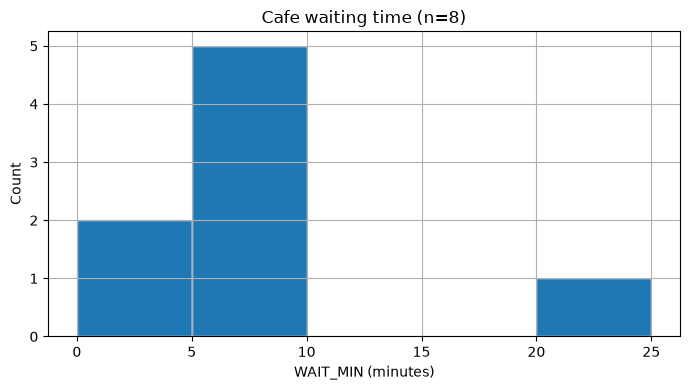

In [60]:
plt.hist(cafe_df["WAIT_MIN"], bins=[0, 5, 10, 15, 20, 25], edgecolor="white")
plt.title("Cafe waiting time (n=8)")
plt.xlabel("WAIT_MIN (minutes)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### What do you observe?

일상 데이터에서 실제로 보인 사실과 추가 설명이 필요한 부분을 나누어 적으세요.

1. 어떤 값 또는 그룹의 분포가 다른가?
2. 이상치로 보이는 값이 있는가?

Observation:
-
-
-

**B. 제조 데이터에 적용 — 질문:** PROCESS_TEMP는 어느 범위에 모이며 떨어진 값이 있을까?

바로 앞 그림과 같은 읽기 순서로 축 → 분포/관계 → 표본 수 → 추가 질문을 확인하세요.

In [64]:
temp_values = df["PROCESS_TEMP"].dropna()
temp_values

0      427.828
1      430.226
2      439.640
3      435.267
4      437.472
        ...   
395    430.497
396    430.209
397    433.384
398    432.635
399    434.037
Name: PROCESS_TEMP, Length: 392, dtype: float64

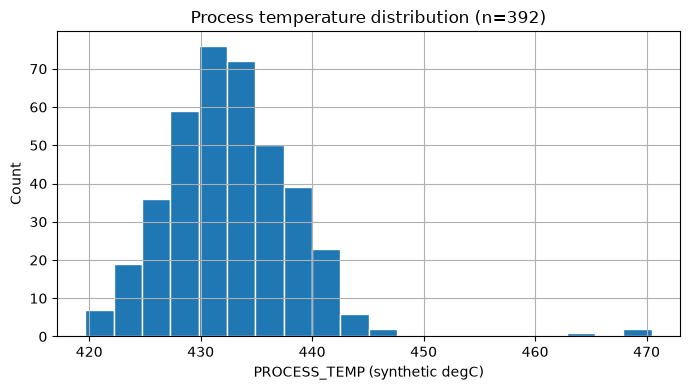

In [65]:
plt.hist(temp_values, bins=20, edgecolor="white")
plt.title(f"Process temperature distribution (n={len(temp_values)})")
plt.xlabel("PROCESS_TEMP (synthetic degC)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### What do you observe?

일상 예제에서 사용한 그래프가 제조 데이터에서는 어떤 질문에 답했나요?

1. 어떤 값 또는 그룹의 분포가 다른가?
2. 이상치로 보이는 값이 있는가?


Observation:
-
-
-

### 10-2. 그룹별 분포 비교

**Boxplot(상자 그림)**은 데이터의 중심과 퍼짐, 다른 값에서 멀리 떨어진 관측값을 요약해 보여주는 그래프입니다. 여러 그룹의 분포를 나란히 비교할 때 유용합니다.

아래처럼 세로로 그린 Boxplot은 다음 순서로 읽습니다.

| 구성 요소 | 의미 | 확인할 것 |
|---|---|---|
| 상자 아래쪽·위쪽 경계 | 제1사분위수 Q1(25%)·제3사분위수 Q3(75%) | 가운데 약 50%의 데이터가 놓인 구간 |
| 상자 안의 가로선 | 중앙값 Q2(50%) | 그룹의 중심이 어느 높이에 있는가? 평균을 뜻하지는 않음 |
| 상자의 세로 길이 | 사분위 범위 IQR = Q3 − Q1 | 길수록 가운데 50% 값이 더 넓게 퍼져 있음 |
| 상자 밖으로 뻗은 세로선과 끝의 가로선 | 아래 설명의 기준 범위 안에서 가장 바깥쪽 관측값까지 표시 | 위아래로 얼마나 뻗어 있는가? |
| 세로선 끝보다 바깥에 있는 점 | 기준 범위를 벗어난 개별 관측값 | 다른 값과 떨어진 이유를 추가로 확인할 후보 |

**IQR(Interquartile Range, 사분위 범위)이란?** 데이터를 작은 값부터 정렬했을 때 **가운데 약 50%에 해당하는 구간의 폭**입니다. 제3사분위수(Q3)에서 제1사분위수(Q1)를 빼서 계산합니다.

- **Q1(제1사분위수)**: 25% 지점에 해당하는 값
- **Q3(제3사분위수)**: 75% 지점에 해당하는 값

$$
IQR = Q3 - Q1
$$

예를 들어 Q1이 4분, Q3가 10분이면 IQR은 6분입니다. Boxplot에서는 상자의 세로 길이에 해당하며, IQR이 클수록 가운데 50%의 값이 더 넓게 퍼져 있습니다.

**상자 밖의 세로선은 어디까지 그릴까요?** 기본 설정에서는 다음 범위 안에 있는 실제 관측값 중 최솟값과 최댓값까지 그립니다.

$$
[Q1 - 1.5\times IQR,\quad Q3 + 1.5\times IQR]
$$

따라서 세로선 끝이 위 계산 경계나 전체 데이터의 최솟값·최댓값과 항상 일치하는 것은 아닙니다. 세로선 끝보다 바깥에 있는 점은 흔히 이상치 후보라고 부르지만, 측정 오류라고 단정하거나 바로 삭제하지 않습니다. [Matplotlib Boxplot 공식 설명](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.boxplot.html)

**비교 순서:** 중앙값의 높이 → 상자의 세로 길이 → 상자 밖 세로선의 길이와 바깥 점을 살펴보세요. 그룹별 관측 수도 함께 확인합니다. 아래 그래프에서 상자의 가로 폭은 관측 수를 나타내지 않습니다.

**A. 간단한 예제 — 질문:** 카페 지점별 대기 시간의 중앙값과 폭이 다를까?


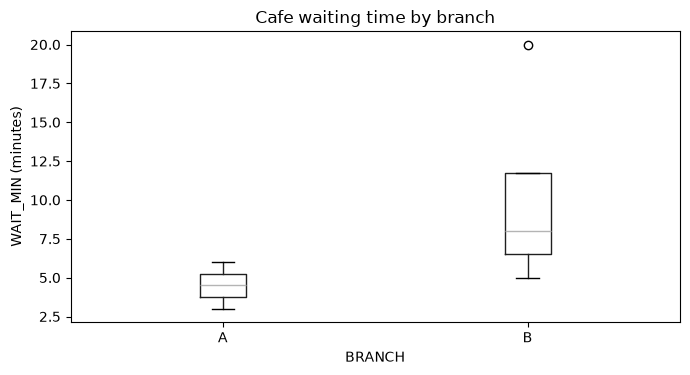

In [175]:
cafe_df.boxplot(column="WAIT_MIN", by="BRANCH", grid=False)
plt.suptitle("")
plt.title("Cafe waiting time by branch")
plt.xlabel("BRANCH")
plt.ylabel("WAIT_MIN (minutes)")
plt.tight_layout()
plt.show()

### What do you observe?

일상 데이터에서 실제로 보인 사실과 추가 설명이 필요한 부분을 나누어 적으세요.

1. 어떤 값 또는 그룹의 분포가 다른가?
2. 이상치로 보이는 값이 있는가?
3. 변수 간 관계를 말할 수 있는가? 단일 변수 그림이라면 다음 비교를 제안하세요.

Observation:
-
-
-

**B. 제조 데이터에 적용 — 질문:** Equipment마다 QUALITY_VALUE 분포가 다를까?

바로 앞 그림과 같은 읽기 순서로 축 → 분포/관계 → 표본 수 → 추가 질문을 확인하세요.

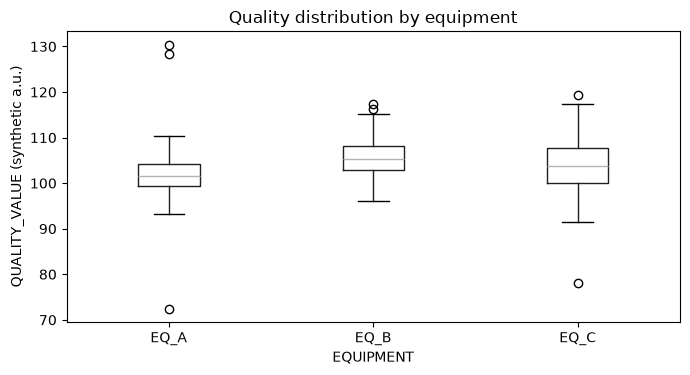

In [71]:
df.boxplot(column="QUALITY_VALUE", by="EQUIPMENT", grid=False)
plt.suptitle("")
plt.title("Quality distribution by equipment")
plt.xlabel("EQUIPMENT")
plt.ylabel("QUALITY_VALUE (synthetic a.u.)")
plt.tight_layout()
plt.show()

### What do you observe?

일상 예제에서 사용한 그래프가 제조 데이터에서는 어떤 질문에 답했나요?

1. 어떤 값 또는 그룹의 분포가 다른가?
2. 이상치로 보이는 값이 있는가?
3. 변수 간 관계를 말할 수 있는가? 단일 변수 그림이라면 다음 비교를 제안하세요.
4. 추가로 확인하고 싶은 것은 무엇인가?

Observation:
-
-
-

### 10-3. 두 변수의 관계

**A. 간단한 예제 — 질문:** 주문 수량이 많으면 대기 시간도 길어지는 모양일까?

점 하나는 주문 한 건입니다. 대체로 함께 증가해도 주문 수량만이 원인이라고 말할 수 없습니다. 지점이나 혼잡도도 관련될 수 있습니다.

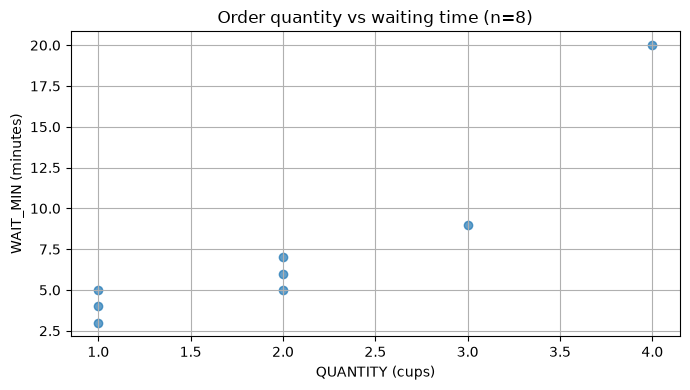

In [176]:
plt.scatter(cafe_df["QUANTITY"], cafe_df["WAIT_MIN"], alpha=0.7)
plt.title("Order quantity vs waiting time (n=8)")
plt.xlabel("QUANTITY (cups)")
plt.ylabel("WAIT_MIN (minutes)")
plt.tight_layout()
plt.show()

### What do you observe?

일상 데이터에서 실제로 보인 사실과 추가 설명이 필요한 부분을 나누어 적으세요.

1. 이상치로 보이는 값이 있는가?
2. 변수 간 관계를 말할 수 있는가? 단일 변수 그림이라면 다음 비교를 제안하세요.
3. 추가로 확인하고 싶은 것은 무엇인가?

Observation:
-
-
-

**B. 제조 데이터에 적용 — 질문:** SENSOR_A와 QUALITY_VALUE 사이에 관계가 있을까?

바로 앞 그림과 같은 읽기 순서로 축 → 분포/관계 → 표본 수 → 추가 질문을 확인하세요.

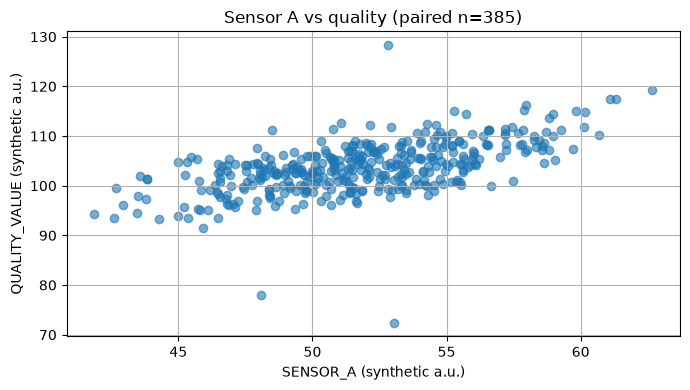

In [177]:
paired_values = df[["SENSOR_A", "QUALITY_VALUE"]].dropna()
plt.scatter(paired_values["SENSOR_A"], paired_values["QUALITY_VALUE"], alpha=0.6)
plt.title(f"Sensor A vs quality (paired n={len(paired_values)})")
plt.xlabel("SENSOR_A (synthetic a.u.)")
plt.ylabel("QUALITY_VALUE (synthetic a.u.)")
plt.tight_layout()
plt.show()

### What do you observe?

일상 예제에서 사용한 그래프가 제조 데이터에서는 어떤 질문에 답했나요?

1. 어떤 값 또는 그룹의 분포가 다른가?
2. 이상치로 보이는 값이 있는가?
3. 변수 간 관계를 말할 수 있는가? 단일 변수 그림이라면 다음 비교를 제안하세요.
4. 추가로 확인하고 싶은 것은 무엇인가?

Observation:
-
-
-

### 10-4. 그룹별 평균 비교

**A. 간단한 예제 — 질문:** 메뉴별 평균 대기 시간은 다를까?

막대는 평균만 보여줍니다. 위 표의 std·count와 함께 읽고, 지점과 수량을 맞춰 비교할 필요가 있는지 질문하세요.

,mean,std,count
MENU,,,
Coffee,5.50,2.516611,4
Tea,9.25,7.274384,4


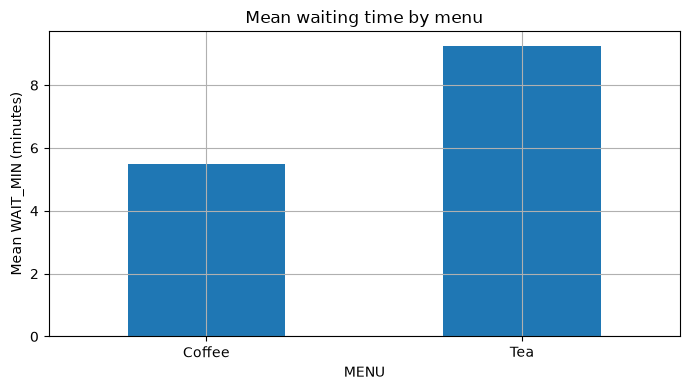

In [66]:
cafe_menu_summary = cafe_df.groupby("MENU")["WAIT_MIN"].agg(["mean", "std", "count"])
display(cafe_menu_summary)
cafe_menu_summary["mean"].plot(kind="bar", rot=0)
plt.title("Mean waiting time by menu")
plt.xlabel("MENU")
plt.ylabel("Mean WAIT_MIN (minutes)")
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()

### What do you observe?

일상 데이터에서 실제로 보인 사실과 추가 설명이 필요한 부분을 나누어 적으세요.

1. 변수 간 관계를 말할 수 있는가? 단일 변수 그림이라면 다음 비교를 제안하세요.
2. 추가로 확인하고 싶은 것은 무엇인가?

Observation:
-
-
-

**B. 제조 데이터에 적용 — 질문:** Product별 QUALITY_VALUE 평균은 다를까?

바로 앞 그림과 같은 읽기 순서로 축 → 분포/관계 → 표본 수 → 추가 질문을 확인하세요.

,mean,std,count
PRODUCT,,,
P_A,103.534456,4.593213,171
P_B,106.086963,6.059237,135
P_C,100.955112,4.004801,89


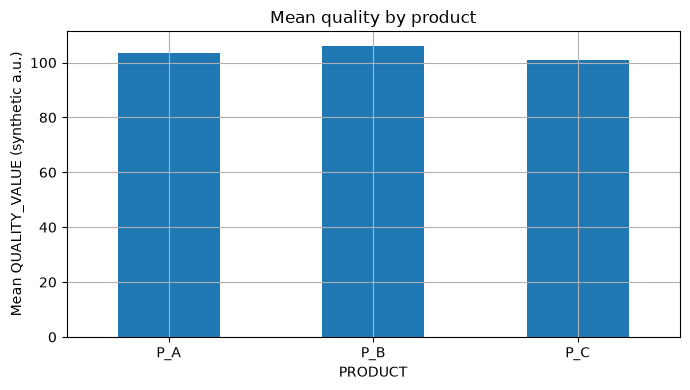

In [179]:
product_summary = df.groupby("PRODUCT")["QUALITY_VALUE"].agg(["mean", "std", "count"])
display(product_summary)
product_summary["mean"].plot(kind="bar", rot=0)
plt.title("Mean quality by product")
plt.xlabel("PRODUCT")
plt.ylabel("Mean QUALITY_VALUE (synthetic a.u.)")
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()

### What do you observe?

일상 예제에서 사용한 그래프가 제조 데이터에서는 어떤 질문에 답했나요?

1. 어떤 값 또는 그룹의 분포가 다른가?
2. 변수 간 관계를 말할 수 있는가? 단일 변수 그림이라면 다음 비교를 제안하세요.
3. 추가로 확인하고 싶은 것은 무엇인가?

Observation:
-
-
-

## 11. 종합 연습: 같은 workflow를 다른 데이터에 적용하기

이제 코드의 대상만 바꾸어 같은 순서를 반복합니다. 앞 절의 예제를 찾아보며 작성해도 됩니다.

| 단계 | A. 간단한 카페 데이터 | B. 제조 데이터 |
|---|---|---|
| Load / Structure | `cafe_missing`의 행·열·dtype 확인 | `df`의 행·열·dtype 확인 |
| Quality | WAIT_MIN의 결측과 유효값 수 | QUALITY_VALUE의 결측과 유효값 수 |
| Summary | BRANCH별 WAIT_MIN의 mean·std·count | EQUIPMENT별 QUALITY_VALUE의 mean·std·count |
| Visualization | 지점별 대기 시간 Boxplot | 장비별 품질값 Boxplot |
| Observation | 보이는 차이와 근거 표본 수 | 보이는 차이와 근거 표본 수 |
| Question | 주문 수량을 맞춰도 차이가 남는가? | Product/Recipe를 맞춰도 차이가 남는가? |

### A. 간단한 데이터로 전체 흐름 연습

In [187]:
# TODO: cafe_missing의 구조와 결측을 확인하세요.
# TODO: BRANCH별 WAIT_MIN을 요약하고 시각화하세요.


Observation:
-

추가로 확인할 질문:
-

### B. 같은 흐름을 제조 데이터에 적용

In [188]:
# TODO: df의 구조와 결측을 확인하세요.
# TODO: EQUIPMENT별 QUALITY_VALUE를 요약하고 시각화하세요.


Observation:
-

추가로 확인할 질문:
-

**완료 점검:** 표본 수·결측 처리·비교 조건을 설명할 수 있나요? 그래프에서 본 사실과 그 이유에 대한 가설을 구분했나요?

다음은 `02_Guided_EDA_Practice.ipynb`입니다. 여기서 배운 순서를 힌트 중심의 문제에 직접 적용합니다.